In [1]:
%%capture
%run '/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/metCostMod-Result.ipynb'
%run '/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/metCost-kineticEnergy.ipynb'

In [2]:
# DEFINE DERIVATIVES
import numpy as np

# Time: 0-15
# X: signal with 15 second
# Ver: x_1

def num_derivative(time, x, ver):
    if ver.lower() == 'x_1':
        version = 2
        x = np.reshape(x, (-1, 1))
    else:
        raise ValueError('Not a valid version')

    delta_t = np.mean(np.diff(time))  # sampling time
    W = 4  # size of the window to be used for the derivative, how many points on either side of center point
    N = 3   # order of interpolating polynomial
    K = round(W / 2)  # center node
    A = np.linspace(-W, 0, W + 1) + K
    A = np.vstack([A * delta_t**n for n in range(N+1)]).T
    R = np.zeros(N+1)
    R[1] = 1
    R = R @ np.linalg.pinv(A.T @ A) @ A.T

    if version != 3:
        x_d = np.zeros_like(x)
    else:
        x_d = {key: np.zeros_like(val) for key, val in x.items()}

    if version == 2:
        for i in range(W - K, len(x) - K):
            x_d[i, :] = R @ x[i - W + K : i + K + 1, 0]
                
    return x_d


In [3]:
import numpy as np
from scipy.signal import convolve

def gaussian_kernel(size, sigma):
    """Create a Gaussian kernel."""
    x = np.linspace(-size // 2, size // 2, size)
    kernel = np.exp(-x**2 / (2 * sigma**2))
    return kernel / np.sum(kernel)

def filterSignal_Gaussian(signal, fs, cutoff):
    """
    Filter a signal using a Gaussian kernel and compute its derivative
    using the derivative of the Gaussian.
    """
    # Kernel size: 1-minute window at fs Hz
    kernel_size = int(fs * 60)
    if kernel_size % 2 == 0:
        kernel_size += 1  # make it odd for symmetry

    # Convert cutoff frequency to Gaussian std in samples
    sigma = fs / (2 * np.pi * cutoff)

    # Create kernels
    g_kernel = gaussian_kernel(kernel_size, sigma)

    # Filter signal
    filtered = convolve(signal, g_kernel, mode='same')

    return filtered

Text(0, 0.5, 'X Accel (m/s^2)')

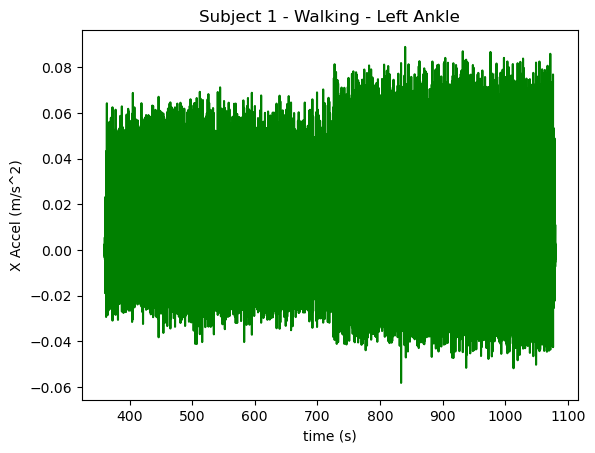

In [4]:
# TEST SUB 1 WALK - ACCEL X

time = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 0]), nan=0.0)
accelX = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 22]), nan=0.0)
accelX_filtered = filterSignal_Gaussian(accelX, 128, 0.1)

derivX = num_derivative(time, accelX, 'x_1')

derivX = derivX[360*128:1080*128]
time = time[360*128:1080*128]

plt.plot(time, derivX, color='green')
plt.title('Subject 1 - Walking - Left Ankle')
plt.xlabel('time (s)')
plt.ylabel('X Accel (m/s^2)')

Text(0, 0.5, 'X Accel (m/s^2)')

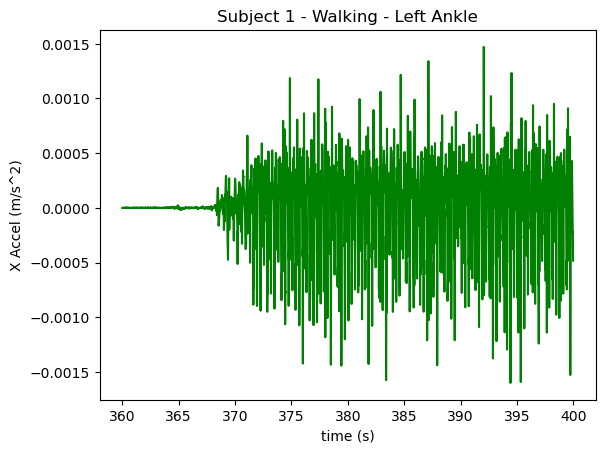

In [6]:
# TEST SUB 1 WALK - ACCEL X

time = np.nan_to_num((result['Subject01']['Walking']['APDM_Accel']['Data'][:, 0]), nan=0.0)
KE = KE_df['total']
KE_f = filterSignal_Gaussian(KE, 128, 0.1)

derivX = num_derivative(time, KE, 'x_1')

derivX = derivX[360*128:400*128]
time = time[360*128:400*128]

plt.plot(time, derivX, color='green')
plt.title('Subject 1 - Walking - Left Ankle')
plt.xlabel('time (s)')
plt.ylabel('X Accel (m/s^2)')